# plots

Avihay Cohen  
March 3, 2025

In [ ]:
rm(list=ls())  # Clear environment

Sys.setenv(LANG = "EN")  # Set environment language to English

if (!requireNamespace("pacman", quietly = TRUE)) install.packages("pacman")
library(pacman)
pacman::p_load(tidyverse, patchwork, RColorBrewer, here, networkD3)

knitr::opts_chunk$set(cache = FALSE,
                      autodep = TRUE,
                      fig.path = here("_output", "index_files", "figure-html"))

# Load _5 for counting with author overlap:

load(here("data", "processed", "dcc_charite_joined_5_au_info.RData"))

# Load the most recent .RData file from the data\processed directory and assign it to "dcc_charite_joined_final"

# Locate dir
files <- list.files(here("data",
                         "processed"), 
                    pattern = "\\.RData$", 
                    full.names = TRUE, 
                    ignore.case = TRUE)

# Identify the latest file based on modification time
latest_file <- files[which.max(file.info(files)$mtime)]

# Load the file into the global environment
loaded_objects <- load(latest_file)

# Assign the loaded object to a new variable name
dcc_charite_joined_final <- get(loaded_objects, envir = .GlobalEnv)
rm(loaded_objects) # clean up


# Exclusion process of cases from the matched list

<br>

# Distinct Number of Papers and Datasets in Found in the DCC

<br>

[1] "Running setup chunk"

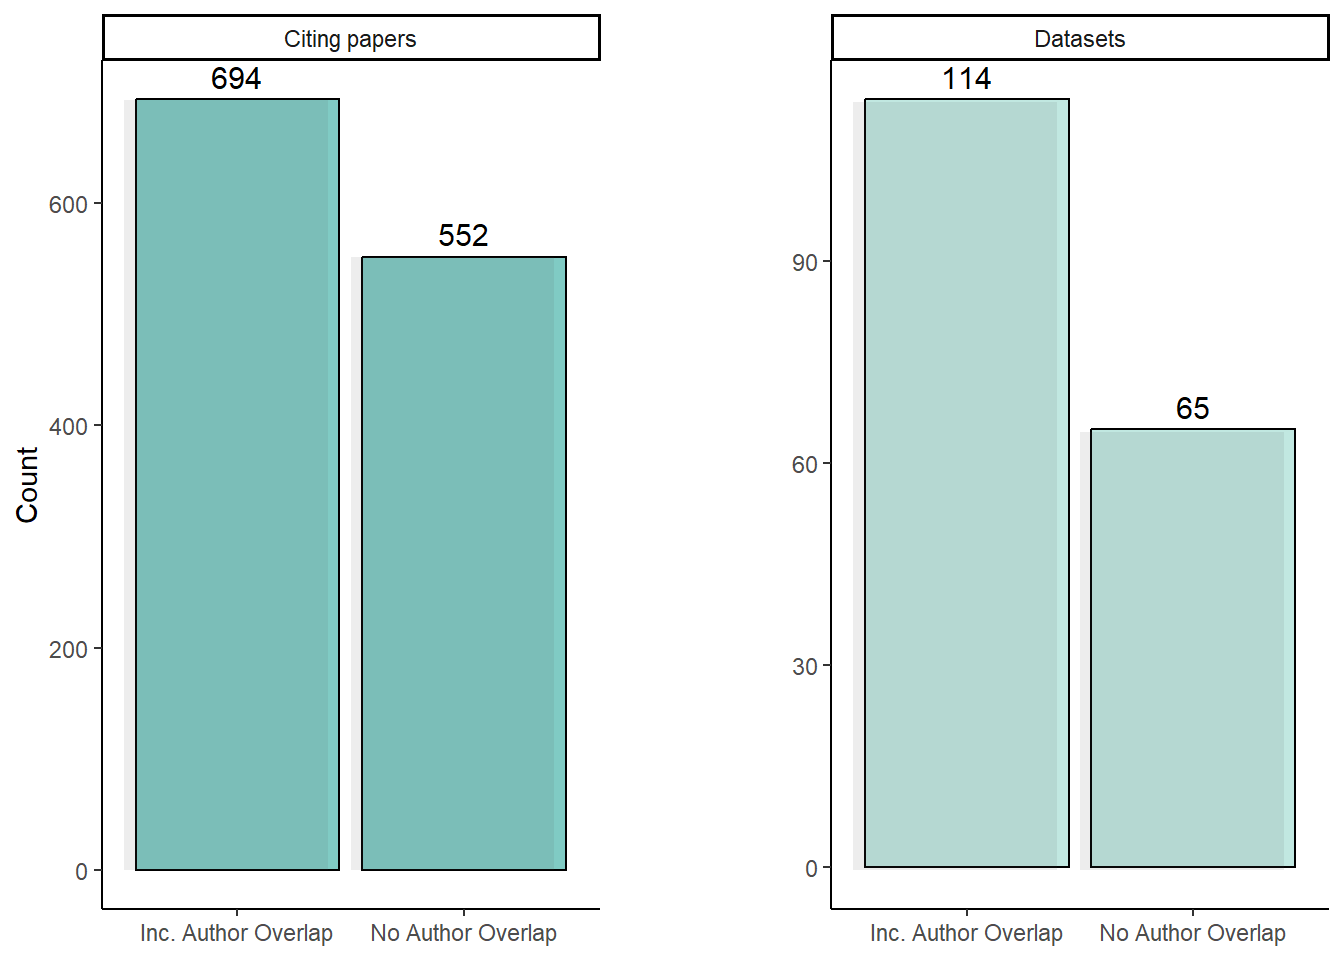

In [ ]:

print("Running setup chunk")


# Distribution Frequency of Datasets References

ℹ Please use `after_stat(count)` instead.

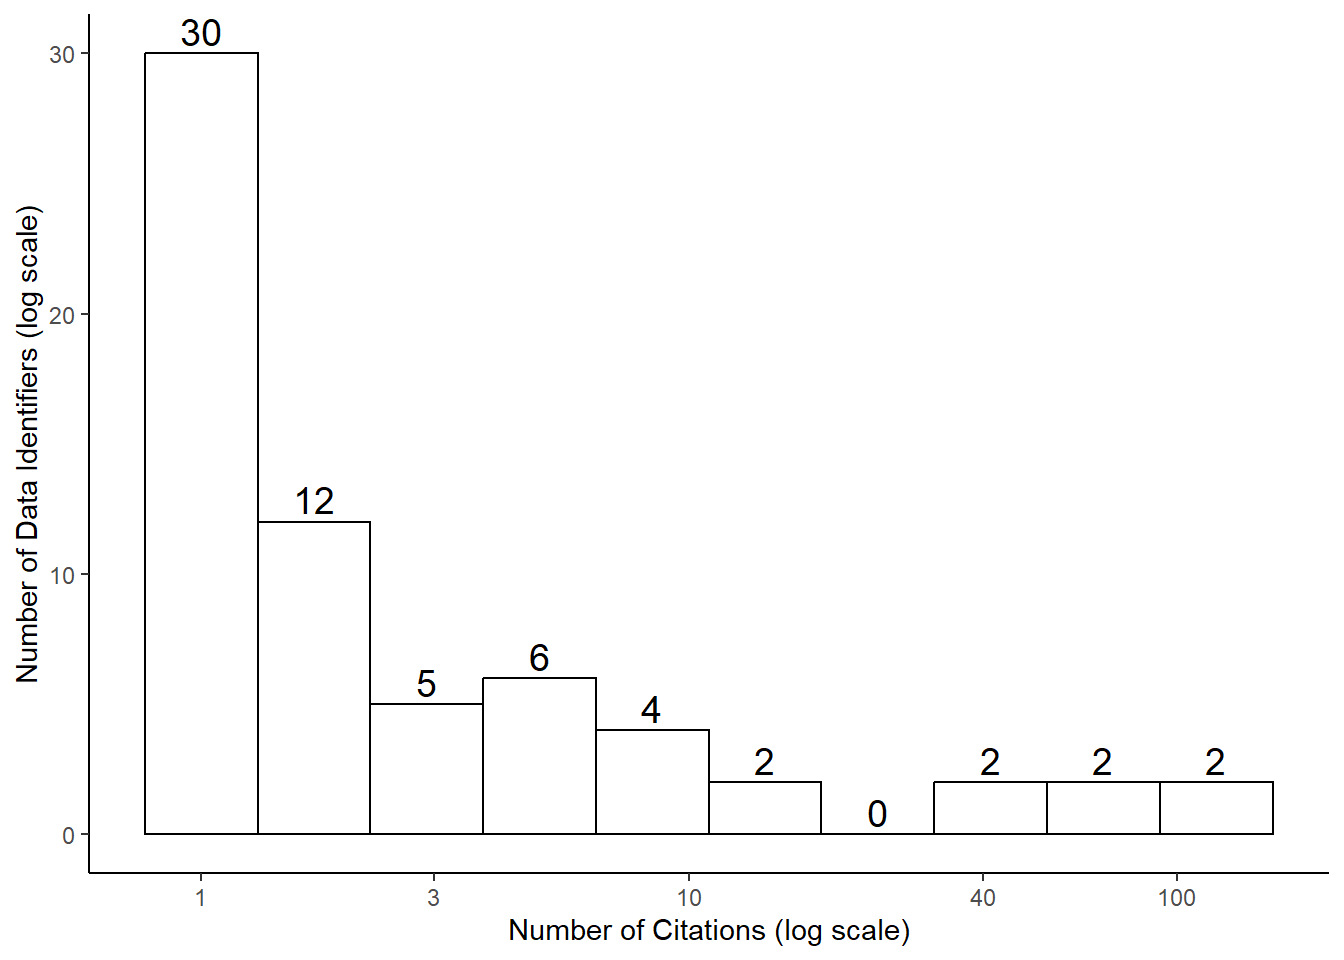

In [ ]:

dcc_charite_joined_final |>
  group_by(charite_data_id_or_acc_nr) |>
  summarise(n = n()) |>
  ggplot(aes(x = n)) +
  geom_histogram(
    bins = 10,                  # Adjust bins to log-scaled data
    color = "black", fill = NA
  ) +
  stat_bin(
    bins = 10,                  # Same binning as histograms
    geom = "text",
    aes(label = ..count..),
    vjust = -0.3,               # Position labels above bars
    size = 5                    # Font size of labels
  ) +
  scale_x_log10(
    breaks = c(1, 3, 10, 40, 100),  # Custom breaks for the x-axis
    labels = c(1, 3, 10, 40, 100)   # Labels for x-axis
  ) +
  labs(
    x = "Number of Citations (log scale)",
    y = "Number of Data Identifiers (log scale)"
  ) +
  theme_classic()


# Distribution of References Across Repositories

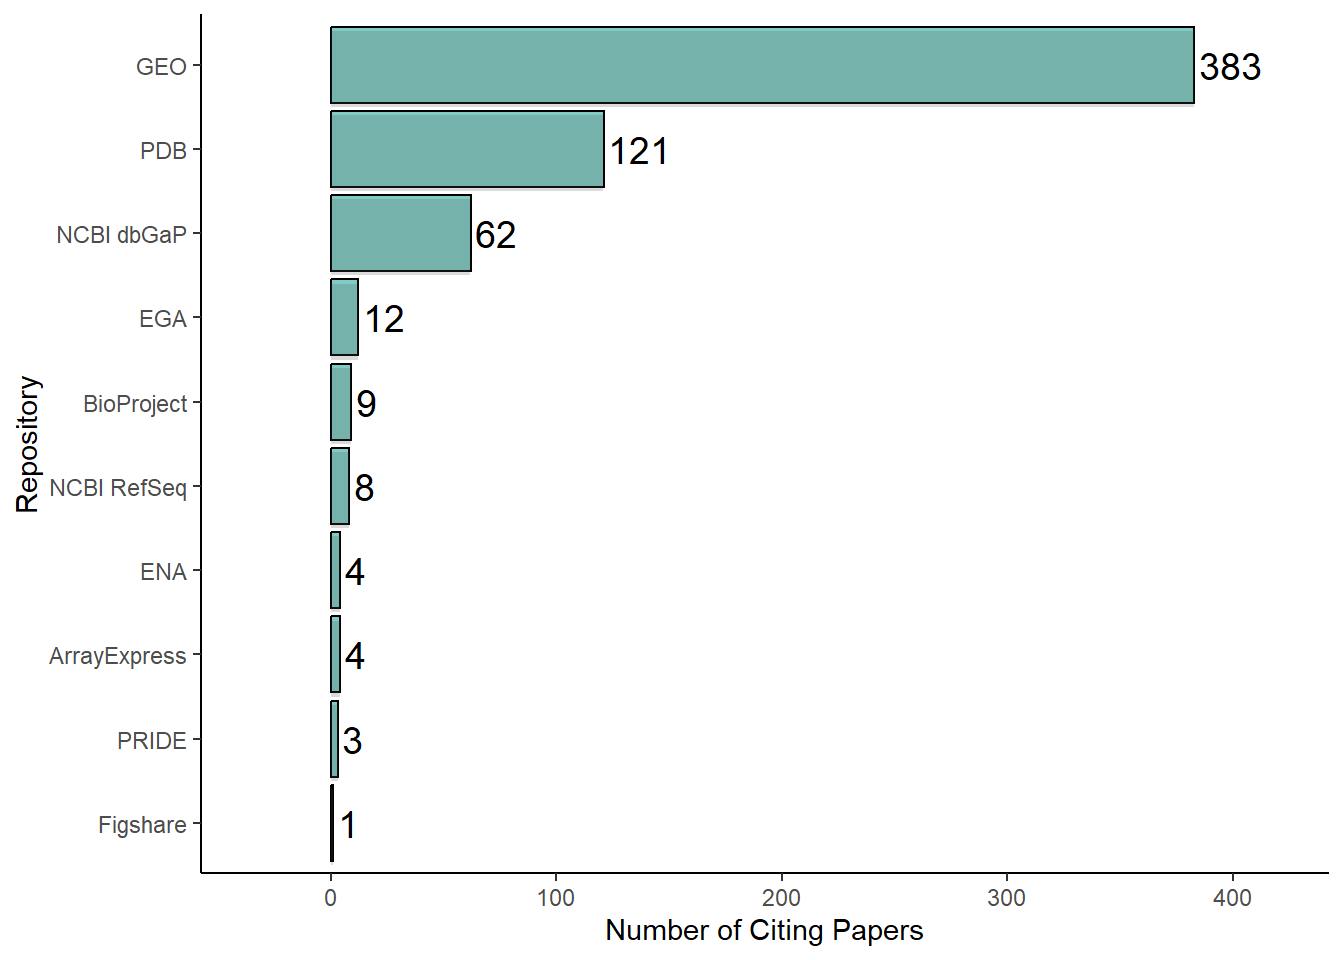

In [ ]:

# Create table

rep_dt <- dcc_charite_joined_final |> 
  group_by(repository) |> 
  summarise(n = n()) |> 
  arrange(desc(n)) |> 
  mutate(repository = case_when(
    repository == "NCBI dbGaP (DataBase of Genotypes And Phenotypesgenotypes and phenotypes)" ~ "NCBI dbGaP",
    repository == "figshare" ~ "Figshare",
    repository == "The European Genome-phenome Archive(EGA)" ~ "EGA",
    repository == "Gene Expression Omnibus (GEO)" ~ "GEO",
    repository == "PRIDE Proteomics Identification Database" ~ "PRIDE",
    repository == "NCBI Reference Sequence Database" ~ "NCBI RefSeq",
    repository == "European Nucleotide Archive" ~ "ENA",
    repository == "The Protein Data Bank" ~ "PDB",
    .default = repository # shorten rep names for a nicer appearance
  ))


rep_dt |>
  ggplot(aes(x = reorder(repository, n), y = n)) +
  geom_bar(stat = "identity",
           position = "dodge",
           fill = "#80CBC4",
           color = "black") +
  geom_bar(stat = "identity", fill = "gray30",
           alpha = 0.2, position = position_nudge(x = -0.05, y = -0.1)) +  # Shadow
geom_text(aes(y = n + 2, label = n),
            vjust = 0.5,
            hjust = 0,
            size = 5, color = "black") + # text next to bars
  scale_y_continuous(expand = expansion(mult = c(0.15, 0.15))) + # Adds 5% padding on both sides of the y-axis
  coord_flip() +
  labs(x = "Repository", y = "Number of Citing Papers") +
  theme_classic()


# Datasets References by Year

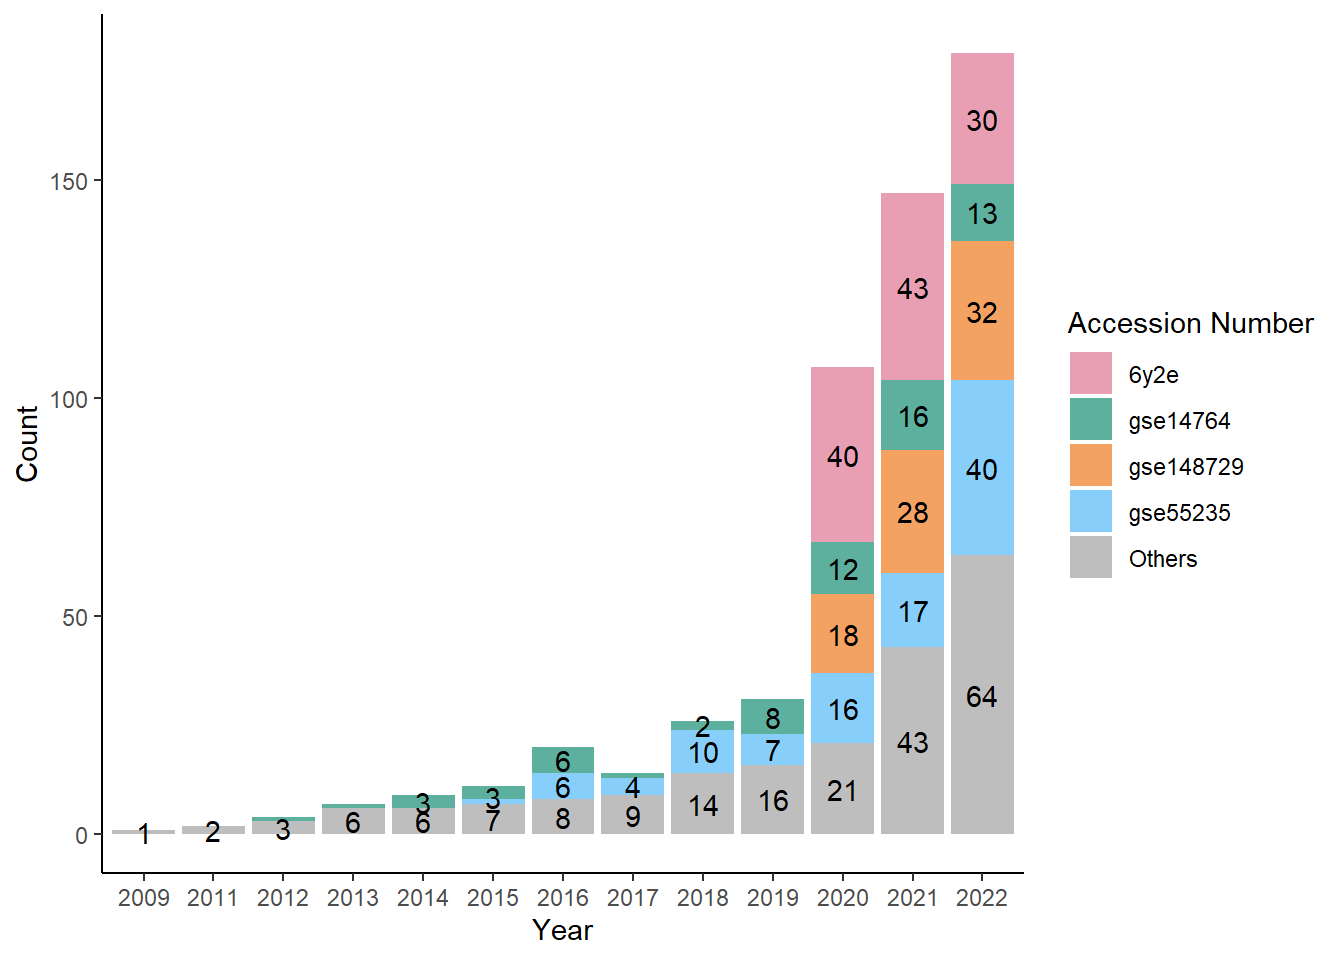

In [ ]:


# Create table

year_dcc_dt_all <- dcc_charite_joined_final |>
  select(doi_dcc, charite_data_id_or_acc_nr, year_dcc) |> 
  distinct() |> 
  count(charite_data_id_or_acc_nr, sort = TRUE)

year_dcc_dt_all_for_plot <- year_dcc_dt_all |>
  inner_join(dcc_charite_joined_final, by = "charite_data_id_or_acc_nr")

year_dcc_dt_all_for_plot_agg <- year_dcc_dt_all_for_plot |> 
  mutate(charite_data_id_or_acc_nr = case_when(
    !charite_data_id_or_acc_nr %in% c("6y2e", "gse14764", "gse148729", "gse55235") ~ "Others",
    .default = charite_data_id_or_acc_nr)) |> 
  group_by(charite_data_id_or_acc_nr, year_dcc) |> 
  summarise(count = n(), .groups = "drop") |> 
  filter(year_dcc != "2023")

ggplot(year_dcc_dt_all_for_plot_agg, aes(x = factor(year_dcc), fill = factor(charite_data_id_or_acc_nr))) +
  geom_bar(stat = "identity",
           position = "stack",
           aes(y = count)) +
geom_text(
  data = year_dcc_dt_all_for_plot_agg |>
    group_by(year_dcc) |>
    filter(!(year_dcc %in% c(2012, 2013, 2015, 2017) & count == min(count))),  # Exclude only in specific years
  aes(y = count, label = count),
  position = position_stack(vjust = 0.5)) +
  labs(
    x = "Year",
    y = "Count",
    fill = "Accession Number"
  ) +
  scale_fill_manual(values = c("#E89FB4", "#5DAF9E", "#F4A261", "#87CEFA", "grey")) +
  theme_classic() #+


# Datasets Access, Repositories and Covid-relationship

In [ ]:

# restricted_info <- manual_validation_done |> 
#   left_join(charite_dois_and_ids_with_access_info, by = "identifier") |> 
#   filter(charite_data_id_or_acc_nr_merged %in% dcc_charite_joined_final$charite_data_id_or_acc_nr) |>
#   select(charite_data_id_or_acc_nr_merged, data_access) |>
#   distinct() |> 
#   group_by(charite_data_id_or_acc_nr_merged) |> 
#   filter(!(is.na(data_access) & n() > 1)) |> 
#   ungroup() |> 
#   rename(charite_data_id_or_acc_nr = charite_data_id_or_acc_nr_merged)
# 
# dcc_charite_for_sankey <- dcc_charite_joined_final |> 
#   select(charite_data_id_or_acc_nr, repository) |>
#   distinct() |> 
#   mutate(acc_nr_or_doi = case_when(str_starts(charite_data_id_or_acc_nr, "10.") ~ "DOI", .default = "Accession Number")) |> 
#   left_join(restricted_info, by = "charite_data_id_or_acc_nr")
# 
# dcc_charite_for_sankey_dummy <- dcc_charite_for_sankey |> 
#   mutate(covid_dummy = sample(c("TRUE", "FALSE"), n(), replace = TRUE))
# 
# # Create a function for verifying the links df structure, extracting its entities and finally plotting it:
# 
# plot_Sankey <- function(links_df, ...) {
#   
#   # 1. Verify that all necessary col names exist
#   stopifnot(all(c("source", "target", "value") %in% names(links_df))) 
#   
#   # 2. Create data frame with unique values ("entities") from "source" and "target" cols
#   nodes <- data.frame(
#     name = c(as.character(links_df$source),
#              as.character(links_df$target))  |> 
#       unique() 
#   )
#   
#   # 3. sankeyNetwork require indexing (0-based, hence the "-1") the nodes' source and target names:
#   links_df$IDsource <- match(links_df$source, nodes$name) - 1
#   links_df$IDtarget <- match(links_df$target, nodes$name) - 1
#   
#   # 4. Now we can insert all of our parameters into the sankeyNetwork arguments:
#   sankeyNetwork(Links = links_df,
#                 Nodes = nodes,
#                 Source = "IDsource",
#                 Target = "IDtarget",
#                 Value = "value",
#                 NodeID = "name",
#                 ...)
#   
# }
# 
# # Create links data frame: accession number - data access - repository - covid
# 
# links_ac_access <- dcc_charite_for_sankey_dummy |>
#   mutate(source = case_when(acc_nr_or_doi == "Accession Number" ~ "Accession Number",
#                             .default = "DOI"),
#          target = case_when(data_access == "yes" ~ "Full Access",
#                             data_access == "restricted" ~ "Restricted Access",
#                             .default = "No Access")) |>
#   count(source, target) |>
#   rename(value = n) |>
#   as.data.frame()
# 
# links_access_rep <- dcc_charite_for_sankey_dummy |>
#   mutate(source = case_when(data_access == "yes" ~ "Full Access",
#                             data_access == "restricted" ~ "Restricted Access",
#                             .default = "No Access"),
#          target = case_when(
#     repository == "NCBI dbGaP (DataBase of Genotypes And Phenotypesgenotypes and phenotypes)" ~ "NCBI dbGaP",
#     repository == "figshare" ~ "Figshare",
#     repository == "The European Genome-phenome Archive(EGA)" ~ "EGA",
#     repository == "Gene Expression Omnibus (GEO)" ~ "GEO",
#     repository == "PRIDE Proteomics Identification Database" ~ "PRIDE",
#     repository == "NCBI Reference Sequence Database" ~ "NCBI RefSeq",
#     repository == "European Nucleotide Archive" ~ "ENA",
#     repository == "The Protein Data Bank" ~ "PDB",
#     .default = repository # shorten rep names for a nicer appearance
#   )) |>
#   count(source, target) |>
#   rename(value = n) |>
#   as.data.frame()
# 
# links_rep_covid <- dcc_charite_for_sankey_dummy |>
#   mutate(source = case_when(
#     repository == "NCBI dbGaP (DataBase of Genotypes And Phenotypesgenotypes and phenotypes)" ~ "NCBI dbGaP",
#     repository == "figshare" ~ "Figshare",
#     repository == "The European Genome-phenome Archive(EGA)" ~ "EGA",
#     repository == "Gene Expression Omnibus (GEO)" ~ "GEO",
#     repository == "PRIDE Proteomics Identification Database" ~ "PRIDE",
#     repository == "NCBI Reference Sequence Database" ~ "NCBI RefSeq",
#     repository == "European Nucleotide Archive" ~ "ENA",
#     repository == "The Protein Data Bank" ~ "PDB",
#     .default = repository # shorten rep names for a nicer appearance
#   ),
#          target = case_when(covid_dummy == "TRUE" ~ "Covid Related",
#                             .default = "Not Covid Related")) |>
#   count(source, target) |>
#   rename(value = n) |>
#   as.data.frame()
# 
# links_all <- links_ac_access |> bind_rows(links_access_rep) |> bind_rows(links_rep_covid)
# 
# plot_Sankey(links_all, sinksRight = FALSE, fontSize = 16) # call the plotting function


# Datasets and Citing Papers Publication Years

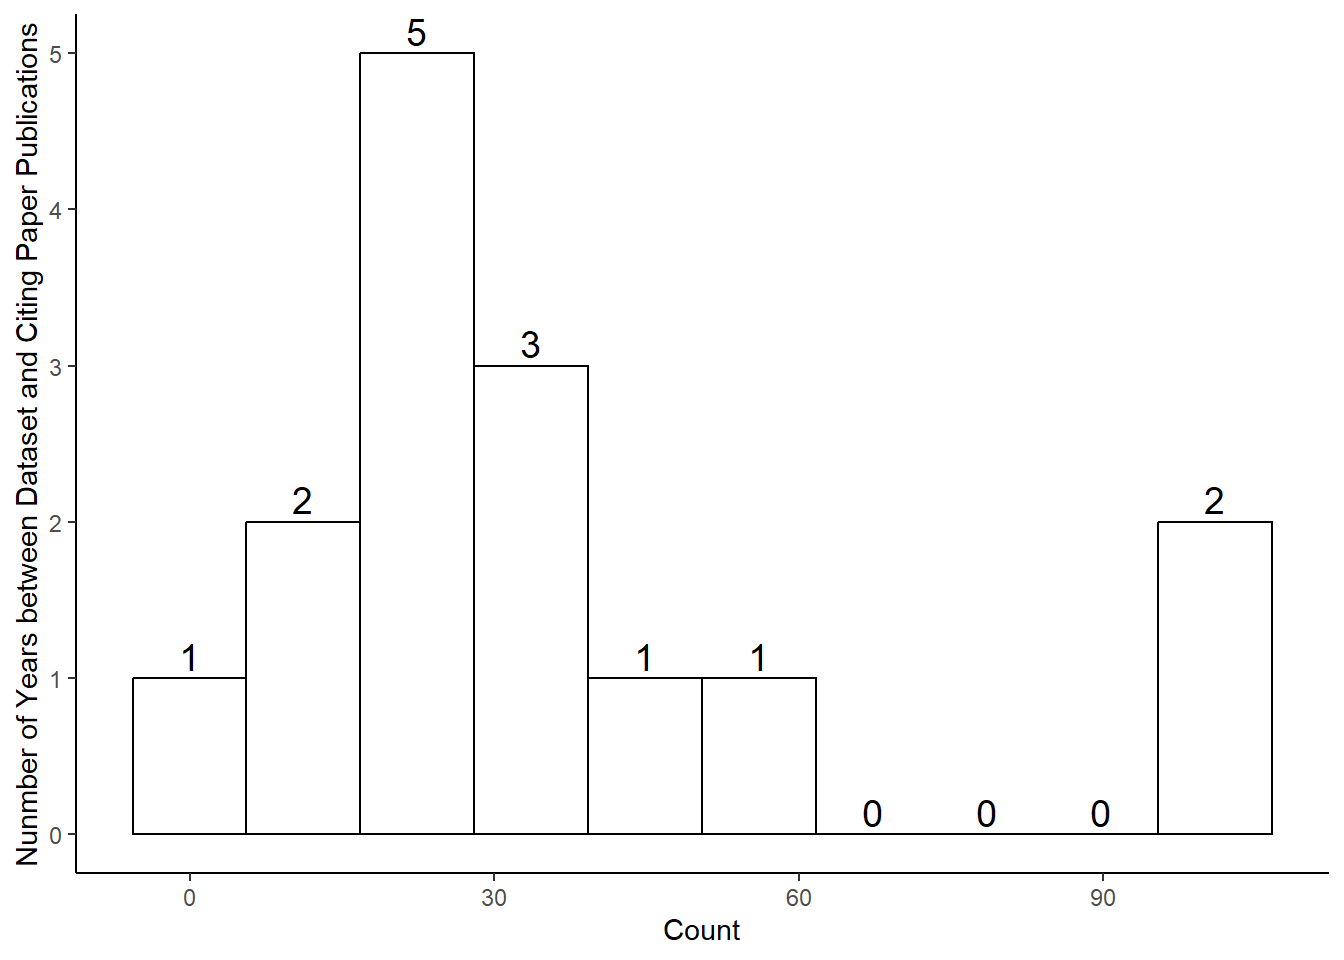

In [ ]:

# Create table

dif_for_plot <- dcc_charite_joined_final |>
  select(doi_charite, doi_dcc, year_dcc, dataset_publication_year) |> 
  distinct() |> 
  mutate(dif = year_dcc - dataset_publication_year) |>
  group_by(dif) |> 
  summarise(n = n())

# Plot

dif_for_plot |>
  filter(dif >= 0) |> 
  ggplot(aes(x = n)) +
  geom_histogram(
    bins = 10,                  # Adjust bins to log-scaled data
    color = "black", fill = NA
  ) +
  stat_bin(
    bins = 10,                  # Same binning as histograms
    geom = "text",
    aes(label = ..count..),
    vjust = -0.3,               # Position labels above bars
    size = 5                    # Font size of labels
  ) +
  # scale_x_log10(
  #   breaks = c(1, 3, 10, 40, 100),  # Custom breaks for the x-axis
  #   labels = c(1, 3, 10, 40, 100)   # Labels for x-axis
  # ) +
  labs(
    x = "Count",
    y = "Nunmber of Years between Dataset and Citing Paper Publications"
  ) +
  theme_classic()
